# Physics-Informed Neural Network (PINN) for an Inverse Problem (Improved)

This notebook demonstrates how to solve an inverse problem using a PINN. We will use sparse and noisy data to infer an unknown parameter in the governing PDE. We will be solving for the thermal diffusivity in the 1D heat equation.

## 1. Problem Setup

We consider the 1D heat equation:
$$ \frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2} $$
where $\alpha$ is the unknown thermal diffusivity. We are given some sparse and noisy measurements of the temperature $u(x, t)$ and the initial and boundary conditions.

- **Domain:** $x \in [0, 1]$ and $t \in [0, 1]$
- **Initial Condition (IC):** $u(x, 0) = \sin(\pi x)$
- **Boundary Conditions (BC):** $u(0, t) = 0$ and $u(1, t) = 0$
- **Data:** We will generate synthetic data from the analytical solution with a known $\alpha_{true}$ and then try to recover this value.

## 2. Implementation (PyTorch)

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

### Define the Neural Network (PINN)
For the inverse problem, we define the unknown parameter, `alpha`, as a trainable parameter of the network.

In [2]:
class PINN_inverse(nn.Module):
    def __init__(self, initial_alpha=0.1):
        super(PINN_inverse, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 50),      # Input: (x, t)
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 1)       # Output: u(x,t)
        )
        # Define alpha as a trainable parameter
        self.alpha = nn.Parameter(torch.tensor([initial_alpha]))

    def forward(self, x, t):
        inputs = torch.cat((x, t), dim=1)
        return self.net(inputs)

### Analytical Solution (for generating data and comparison)

In [3]:
def u_analytical(x, t, alpha):
    return torch.exp(-alpha * (np.pi**2) * t) * torch.sin(np.pi * x)

### Generate Training Data
We generate data using a `true_alpha` and then try to recover it.

In [4]:
true_alpha = 1.0 / (np.pi**2) # This is the value we want to find

# Collocation points for PDE residual
num_pde_points = 10000
x_pde = torch.rand(num_pde_points, 1, requires_grad=True)
t_pde = torch.rand(num_pde_points, 1, requires_grad=True)

# Initial and Boundary conditions
num_ic_points = 200
x_ic = torch.rand(num_ic_points, 1)
t_ic = torch.zeros(num_ic_points, 1)
u_ic_exact = u_analytical(x_ic, t_ic, true_alpha)

num_bc_points = 200
x_bc0 = torch.zeros(num_bc_points, 1)
t_bc0 = torch.rand(num_bc_points, 1)
u_bc0_exact = u_analytical(x_bc0, t_bc0, true_alpha)

x_bc1 = torch.ones(num_bc_points, 1)
t_bc1 = torch.rand(num_bc_points, 1)
u_bc1_exact = u_analytical(x_bc1, t_bc1, true_alpha)

# Sparse, noisy data points for the inverse problem
num_data_points = 100
x_data = torch.rand(num_data_points, 1)
t_data = torch.rand(num_data_points, 1)
u_data_exact = u_analytical(x_data, t_data, true_alpha)
u_data_noisy = u_data_exact + 0.02 * torch.randn_like(u_data_exact)

### Loss Functions

In [5]:
def pde_loss_fn(model, x, t):
    u = model(x, t)
    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    pde_residual = u_t - model.alpha * u_xx
    return torch.mean(pde_residual**2)

def ic_loss_fn(model, x, t, u_exact):
    u_pred = model(x, t)
    return torch.mean((u_pred - u_exact)**2)

def bc_loss_fn(model, x, t, u_exact):
    u_pred = model(x, t)
    return torch.mean((u_pred - u_exact)**2)

def data_loss_fn(model, x, t, u_noisy):
    u_pred = model(x, t)
    return torch.mean((u_pred - u_noisy)**2)

### Training Loop

In [6]:
pinn_inverse_model = PINN_inverse(initial_alpha=0.5) # Start with a guess for alpha
optimizer = torch.optim.Adam(pinn_inverse_model.parameters(), lr=0.001)
epochs = 15000

# Loss weights
lambda_pde = 1.0
lambda_ic = 100.0
lambda_bc = 100.0
lambda_data = 200.0

alpha_history = []

print(f"True alpha: {true_alpha:.6f}")
print("Starting PINN training for inverse problem...")

for epoch in range(epochs):
    optimizer.zero_grad()
    
    # Calculate losses
    loss_pde = pde_loss_fn(pinn_inverse_model, x_pde, t_pde)
    loss_ic = ic_loss_fn(pinn_inverse_model, x_ic, t_ic, u_ic_exact)
    loss_bc0 = bc_loss_fn(pinn_inverse_model, x_bc0, t_bc0, u_bc0_exact)
    loss_bc1 = bc_loss_fn(pinn_inverse_model, x_bc1, t_bc1, u_bc1_exact)
    loss_data = data_loss_fn(pinn_inverse_model, x_data, t_data, u_data_noisy)
    
    loss_bc = loss_bc0 + loss_bc1
    
    # Total loss
    total_loss = (lambda_pde * loss_pde + 
                  lambda_ic * loss_ic + 
                  lambda_bc * loss_bc + 
                  lambda_data * loss_data)
    
    total_loss.backward()
    optimizer.step()
    
    # Store alpha history for plotting
    alpha_history.append(pinn_inverse_model.alpha.item())
    
    if (epoch + 1) % 1000 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss.item():.6f}, Estimated alpha: {pinn_inverse_model.alpha.item():.6f}")

print("Training complete!")
print(f"Final estimated alpha: {pinn_inverse_model.alpha.item():.6f}")

True alpha: 0.101321
Starting PINN training for inverse problem...
Epoch 1000/15000, Loss: 0.335087, Estimated alpha: 0.103688
Epoch 2000/15000, Loss: 0.081847, Estimated alpha: 0.099942
Epoch 3000/15000, Loss: 0.081352, Estimated alpha: 0.099954
Epoch 4000/15000, Loss: 0.086714, Estimated alpha: 0.099932
Epoch 5000/15000, Loss: 0.080505, Estimated alpha: 0.099898
Epoch 6000/15000, Loss: 0.114729, Estimated alpha: 0.099883
Epoch 7000/15000, Loss: 0.079653, Estimated alpha: 0.099868
Epoch 8000/15000, Loss: 0.079284, Estimated alpha: 0.099864
Epoch 9000/15000, Loss: 0.079156, Estimated alpha: 0.099854
Epoch 10000/15000, Loss: 0.182729, Estimated alpha: 0.099824
Epoch 11000/15000, Loss: 0.078279, Estimated alpha: 0.099793
Epoch 12000/15000, Loss: 0.077844, Estimated alpha: 0.099751
Epoch 13000/15000, Loss: 0.077620, Estimated alpha: 0.099707
Epoch 14000/15000, Loss: 0.080730, Estimated alpha: 0.099692
Epoch 15000/15000, Loss: 0.077136, Estimated alpha: 0.099651
Training complete!
Final es

### Visualization of Alpha Convergence

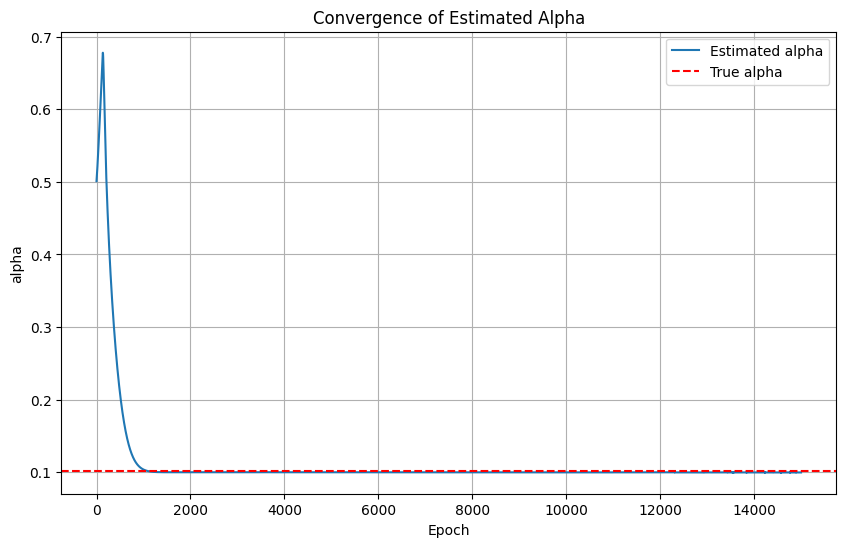

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(alpha_history, label='Estimated alpha')
plt.axhline(y=true_alpha, color='r', linestyle='--', label='True alpha')
plt.xlabel('Epoch')
plt.ylabel('alpha')
plt.title('Convergence of Estimated Alpha')
plt.legend()
plt.grid(True)
plt.show()